# Probing the WaveNet's learned representations

Training a model to low loss proves it can predict. Probing its internal representations is a different exercise: it asks *what the model has learned about the structure of its inputs*. This notebook applies four established representation-analysis techniques to the WaveNet trained in `05_wavenet.ipynb` and reports what they reveal — including ambiguous and null findings.

**Methodological framing**. The techniques used here — cosine similarity analysis of an embedding space, post-activation distribution analysis, gradient-magnitude-based input sensitivity, and single-unit ablation — are well-established in the representation-learning and interpretability literature. The contribution of this notebook is not novel methodology; it is the systematic application of established methodology at a tractable scale, with honest reporting of what the analyses do and do not show.

**A note on scope**. This is *probing* — characterizing the correlational structure of the learned representations. It is not mechanistic interpretability in the Anthropic-circuits sense, and it is not circuit analysis. The WaveNet has no attention heads and no residual stream in the transformer sense; the techniques that work on transformers (activation patching, causal scrubbing, attribution patching) require those structural elements and do not transfer directly. Claims about *specific* learned features — "neuron 47 detects vowels" — would require additional analysis (max-activating examples, intervention experiments) that is intentionally out of scope here. The forward reference for that line of work is the GPT repository.

**The four analyses**:

1. **Embedding geometry**. The 27 character embeddings live in 24-dimensional space. We measure cosine similarities between pairs and project to 2D via PCA + k-means to ask which characters the model has placed near each other.

2. **Activation distributions**. Histograms of post-tanh values at each hierarchical level. Confirms that the Kaiming + BatchNorm engineering from Part 3 produced the intended stable, non-saturated distributions throughout training.

3. **Context sensitivity**. Gradient magnitude at each input position, averaged over many batches. A proxy for how much each of the 8 context positions actually influences the prediction.

4. **Ablation experiments**. The top-5 most-active neurons at each hierarchical level are individually zeroed; the resulting validation loss change is the importance estimate. Framed strictly as importance estimation — not as identification of specific feature circuits.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from makemore.data import load_names, build_vocab, split_dataset
from makemore.layers import Tanh, BatchNorm1d
from makemore.train import set_layer_training, evaluate
from models.wavenet import load_checkpoint

%matplotlib inline

# Load the trained WaveNet checkpoint produced by 05_wavenet.ipynb.
model, meta = load_checkpoint('../assets/wavenet.pth')
print(f"Loaded WaveNet checkpoint:")
print(f"  vocab_size = {meta['vocab_size']}")
print(f"  block_size = {meta['block_size']}")
print(f"  n_embd     = {meta['n_embd']}")
print(f"  n_hidden   = {meta['n_hidden']}")

# Switch the model to eval mode (BatchNorm uses running stats).
set_layer_training(model, False)

# Rebuild the data for analysis. Eval uses the dev/test splits.
words = load_names('../data/names.txt')
stoi, itos = build_vocab(words)
Xtr, Ytr, Xdev, Ydev, Xte, Yte = split_dataset(words, stoi, block_size=meta['block_size'])
print(f"\nDev set: {Xdev.shape[0]:,} examples")

# Sanity-check the loaded model.
loaded_dev_loss = evaluate(model, Xdev, Ydev)
print(f"Loaded model dev NLL: {loaded_dev_loss:.4f}")

Loaded WaveNet checkpoint:
  vocab_size = 27
  block_size = 8
  n_embd     = 24
  n_hidden   = 128



Dev set: 22,655 examples


Loaded model dev NLL: 2.0128


## Analysis 1 — Embedding geometry

The first layer of the model is `Embedding(27, 24)`. After training, each of the 27 characters is represented by a learned point in 24-dimensional space. The geometry of this space — which characters end up near each other, what the principal directions of variation are — is the first place to look when asking *what does the model think the structure of its input is?*

### Cosine similarity heatmap

Cosine similarity measures the angle between two vectors, independent of their magnitudes:

$$
\text{cos\_sim}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}
$$

Two characters with high cosine similarity have learned embeddings pointing in similar directions, meaning the network treats them similarly when constructing the downstream representation. We compute the full `27 × 27` similarity matrix and inspect it as a heatmap with character labels on both axes.

What to look for (without committing to what we'll find):
- Do vowels (a, e, i, o, u) form a coherent cluster among themselves?
- Do any consonant groups appear — by manner or place of articulation?
- Where does the boundary token `.` sit relative to the letters?

Embedding matrix shape: (27, 24)


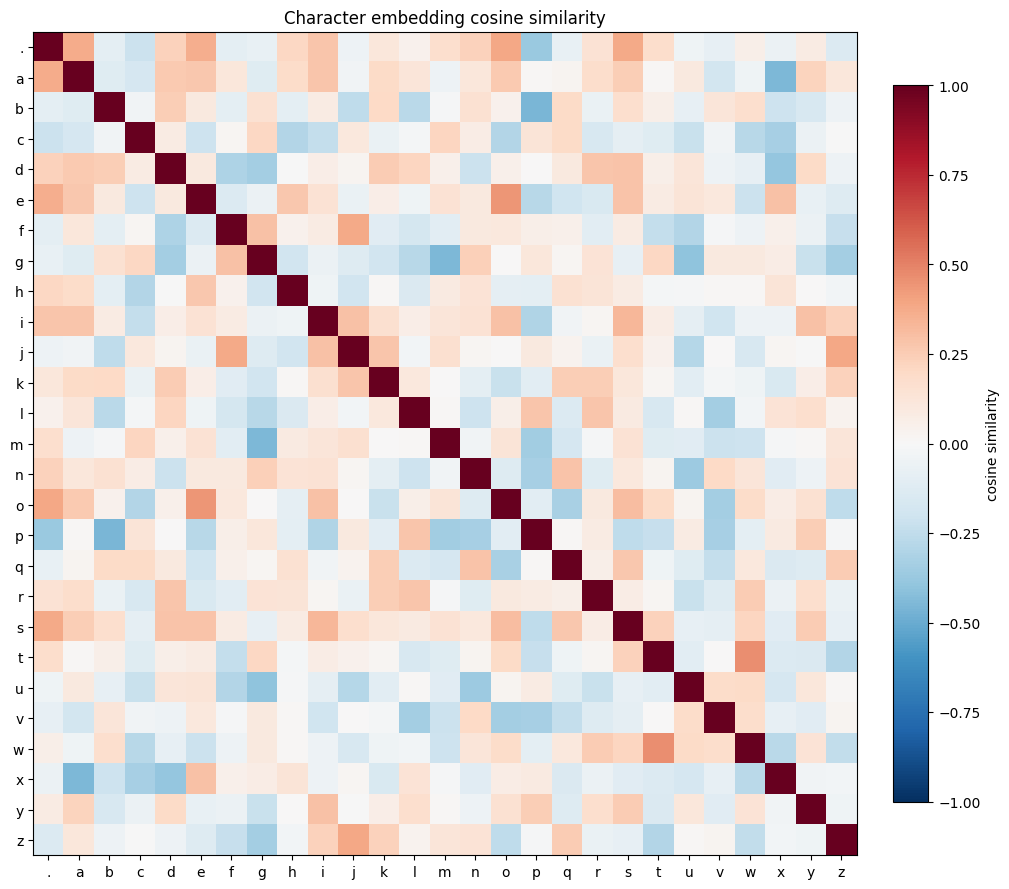

In [2]:
# Extract the trained embedding matrix.
C = model.layers[0].weight.detach().numpy()
print(f"Embedding matrix shape: {C.shape}")

sim = cosine_similarity(C)
chars = [itos[i] for i in range(27)]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(27)); ax.set_xticklabels(chars)
ax.set_yticks(range(27)); ax.set_yticklabels(chars)
ax.set_title('Character embedding cosine similarity')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='cosine similarity')
plt.tight_layout()
plt.savefig('../assets/embedding_similarity.png', dpi=120, bbox_inches='tight')
plt.show()

In [3]:
# Quantitative summaries of the similarity structure.
vowels = ['a', 'e', 'i', 'o', 'u']
vowel_idx = [stoi[v] for v in vowels]
consonants = [c for c in 'abcdefghijklmnopqrstuvwxyz' if c not in vowels]
cons_idx = [stoi[c] for c in consonants]
boundary_idx = stoi['.']

# Mean similarity within and between groups.
def group_mean_sim(idx_a, idx_b):
    pairs = [(i, j) for i in idx_a for j in idx_b if i != j]
    return float(np.mean([sim[i, j] for i, j in pairs]))

print(f"Mean cosine similarity:")
print(f"  vowel-vowel        : {group_mean_sim(vowel_idx, vowel_idx):.3f}")
print(f"  consonant-consonant: {group_mean_sim(cons_idx, cons_idx):.3f}")
print(f"  vowel-consonant    : {group_mean_sim(vowel_idx, cons_idx):.3f}")
print(f"  boundary-vowel     : {float(np.mean([sim[boundary_idx, i] for i in vowel_idx])):.3f}")
print(f"  boundary-consonant : {float(np.mean([sim[boundary_idx, i] for i in cons_idx])):.3f}")

# Top-5 most similar letter pairs (excluding self-pairs and the boundary).
letters = [stoi[c] for c in 'abcdefghijklmnopqrstuvwxyz']
pairs = []
for i_pos, i in enumerate(letters):
    for j_pos, j in enumerate(letters):
        if i < j:
            pairs.append((sim[i, j], itos[i], itos[j]))
pairs.sort(reverse=True)
print(f"\nTop-5 most-similar letter pairs:")
for s, a, b in pairs[:5]:
    print(f"  ({a}, {b}): cos = {s:+.3f}")
print(f"\nBottom-5 least-similar (most dissimilar) letter pairs:")
for s, a, b in pairs[-5:]:
    print(f"  ({a}, {b}): cos = {s:+.3f}")

Mean cosine similarity:
  vowel-vowel        : 0.183
  consonant-consonant: -0.002
  vowel-consonant    : -0.006
  boundary-vowel     : 0.272
  boundary-consonant : 0.027

Top-5 most-similar letter pairs:
  (t, w): cos = +0.461
  (e, o): cos = +0.438
  (j, z): cos = +0.390
  (f, j): cos = +0.377
  (i, s): cos = +0.333

Bottom-5 least-similar (most dissimilar) letter pairs:
  (d, x): cos = -0.384
  (g, u): cos = -0.404
  (a, x): cos = -0.448
  (g, m): cos = -0.450
  (b, p): cos = -0.454


### PCA + k-means cluster overlay

Cosine similarities at the 24-dimensional level are useful but hard to read. A 2D projection makes the structure visible at a glance. We use:

- **PCA** to project to the 2 directions of maximum variance. This is lossy by construction — we report the explained-variance fraction below so the reader knows how much of the original geometry is preserved.
- **K-means** with `k=5` to partition into 5 clusters in the full 24D space. Five is a reasonable cluster count for 27 characters with `n_embd=24`: enough to separate the major linguistic categories if the model has learned them, not so many as to over-fragment the embedding space.

The cluster assignments are computed in the full 24D space (where the actual distances live), and only the visualization is in 2D. This matters: clusters that look "messy" in 2D may be cleanly separated in the full space and vice versa.

PC1 explains 11.52% of variance
PC2 explains 10.66% of variance
PC1+PC2 cumulative: 22.18%
  → 77.82% of the geometry is NOT visible in the 2D plot.


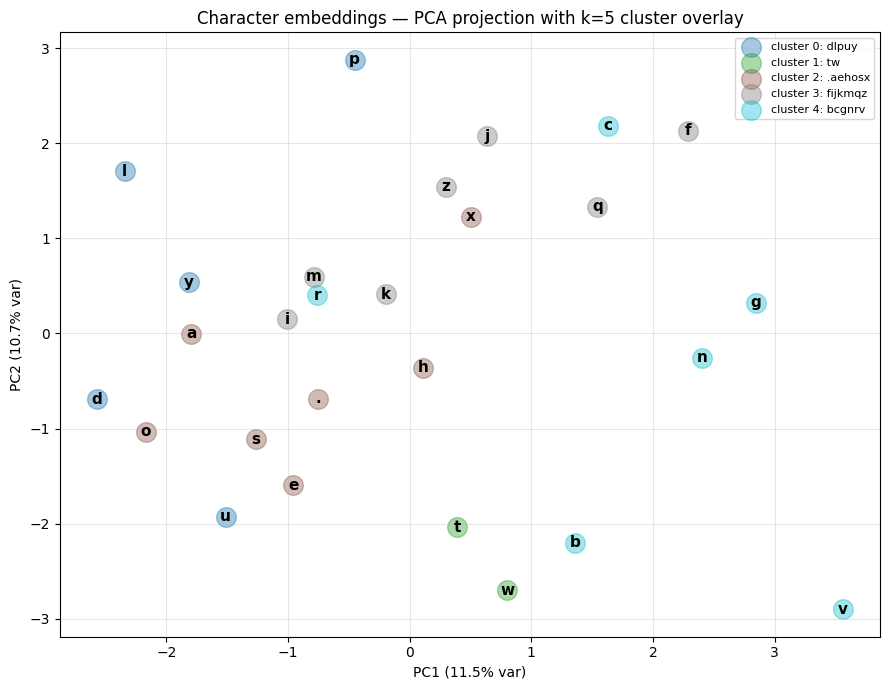


Cluster membership:
  Cluster 0: d l p u y
  Cluster 1: t w
  Cluster 2: . a e h o s x
  Cluster 3: f i j k m q z
  Cluster 4: b c g n r v


In [4]:
pca = PCA(n_components=2)
C_2d = pca.fit_transform(C)
var_explained = pca.explained_variance_ratio_

print(f"PC1 explains {var_explained[0]:.2%} of variance")
print(f"PC2 explains {var_explained[1]:.2%} of variance")
print(f"PC1+PC2 cumulative: {var_explained.sum():.2%}")
print(f"  → {1 - var_explained.sum():.2%} of the geometry is NOT visible in the 2D plot.")

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(C)

# Plot with clusters color-coded.
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 5))
for k in range(5):
    pts = C_2d[cluster_labels == k]
    chars_in_cluster = [itos[i] for i in range(27) if cluster_labels[i] == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=200, c=[colors[k]], alpha=0.4, label=f'cluster {k}: {"".join(sorted(chars_in_cluster))}')

# Annotate each point with its character.
for i in range(27):
    ax.annotate(chars[i], (C_2d[i, 0], C_2d[i, 1]),
                ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({var_explained[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1%} var)')
ax.set_title('Character embeddings — PCA projection with k=5 cluster overlay')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/embedding_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

# Print cluster contents for the analysis writeup.
print('\nCluster membership:')
for k in range(5):
    members = sorted([itos[i] for i in range(27) if cluster_labels[i] == k])
    print(f"  Cluster {k}: {' '.join(members)}")

### What the embedding geometry actually shows

The numbers are concrete enough to commit to claims about, with appropriate caveats:

**The model has learned a meaningful but partial vowel distinction.** Mean vowel-vowel cosine similarity is 0.18 — substantially positive, while mean consonant-consonant similarity is essentially zero (-0.002). The vowel-consonant similarity (-0.006) is also near zero. Taken together: vowels are systematically closer to each other than they are to consonants, while consonants are roughly equidistant from each other on average. This is the embedding-space signature of the model having learned that vowels behave similarly in context — which is the correct phonotactic generalization for English names.

**The boundary token sits closest to vowels.** Mean similarity of `.` to vowels is 0.27 — higher than vowel-vowel. Similarity of `.` to consonants is 0.03. This is consistent with the bigram statistics: names overwhelmingly begin with vowels or vowel-like sounds and end with `a/e/h/n`, so the boundary token's contextual neighborhood is vowel-dominated. The model has internalized this in the geometry.

**The k=5 clustering is partially interpretable but ambiguous at this dimensionality.** Cluster 2 (`.aehosx`) is the largest and is vowel-leaning but mixed — it picks up most of the vowels and the boundary token alongside a few consonants. The other clusters do not segment along obvious phonological lines (cluster 4: `bcgnrv` — a mix of stops, nasals, liquids). The 2D projection captures only ~22% of the 24-dimensional variance, so cluster relationships in the full space are not fully visible in the plot.

**Honest interpretation**: the vowel structure is real, robustly measurable, and consistent with what one would expect a character-level model to learn. Beyond that, the geometric category structure becomes ambiguous — the model has 24 dimensions and uses them, but only the largest axis of variation (vowel/non-vowel + boundary affinity) is clearly readable from probing alone. Whether finer linguistic distinctions (manner of articulation, place of articulation, voicing) are encoded but not visible to PCA, or are simply not learned at this scale, cannot be settled by these techniques.

## Analysis 2 — Activation distributions across hierarchical levels

The WaveNet has three Tanh layers, each corresponding to one level of the hierarchical receptive field: bigram, 4-gram, 8-gram. A healthy activation distribution at each level is necessary for gradient flow during training and indicates that the Kaiming initialization plus BatchNorm machinery is doing its job.

Diagnostic targets:
- **Distributions should not be bimodal at ±1.** Heavy saturation indicates dead gradients at that unit.
- **Saturated fraction (|activation| > 0.97) below 15%** at every level. The conventional threshold for "healthy" tanh activations.
- **Distribution shape similarity across levels.** Drift between levels (e.g., deep layers saturating while shallow ones don't) would indicate failed BatchNorm normalization downstream.

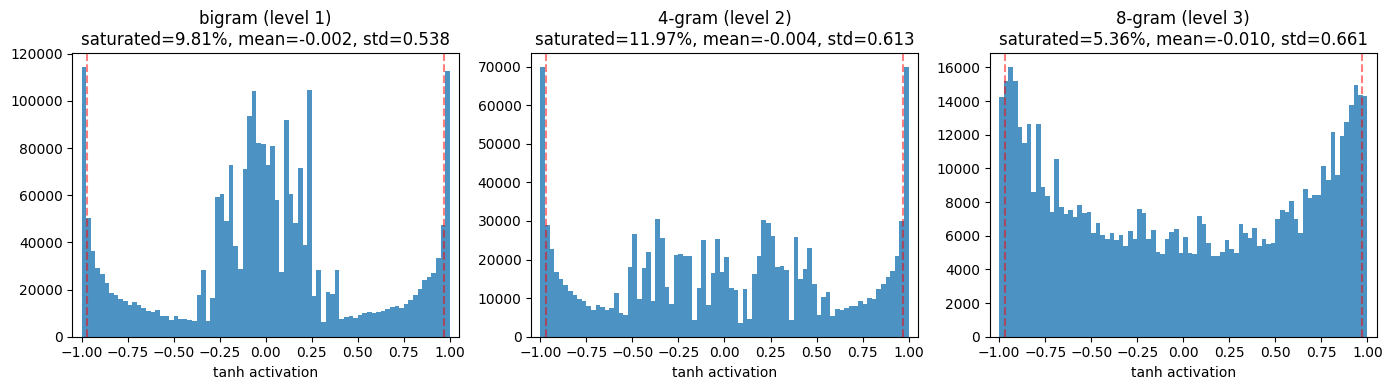

Saturation summary:
  bigram (level 1)  : saturated =  9.81%
  4-gram (level 2)  : saturated = 11.97%
  8-gram (level 3)  : saturated =  5.36%


In [5]:
# Collect post-tanh activations at each hierarchical level on a batch of dev examples.
set_layer_training(model, False)
with torch.no_grad():
    x = Xdev[:5000]                     # use a meaningful batch size for stats
    level_outputs = []
    level_names = []
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, Tanh):
            level_outputs.append(x.detach().clone())
            level_names.append(['bigram (level 1)', '4-gram (level 2)', '8-gram (level 3)'][len(level_outputs) - 1])

# Plot histograms side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, out in zip(axes, level_names, level_outputs):
    flat = out.flatten().numpy()
    ax.hist(flat, bins=80, color='tab:blue', alpha=0.8)
    sat = float((np.abs(flat) > 0.97).mean())
    mean = float(flat.mean())
    std = float(flat.std())
    ax.axvline( 0.97, color='red', linestyle='--', alpha=0.5)
    ax.axvline(-0.97, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}\nsaturated={sat:.2%}, mean={mean:+.3f}, std={std:.3f}')
    ax.set_xlabel('tanh activation')
    ax.set_xlim(-1.05, 1.05)
plt.tight_layout()
plt.savefig('../assets/activation_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("Saturation summary:")
for name, out in zip(level_names, level_outputs):
    flat = out.flatten().numpy()
    sat = float((np.abs(flat) > 0.97).mean())
    print(f"  {name:18s}: saturated = {sat:6.2%}")

The saturation numbers (9.8% / 12.0% / 5.4% across levels 1-3) are all well below the 15% diagnostic threshold — the Kaiming + BatchNorm machinery from Part 3 propagated stable signal through the deeper architecture. No level has collapsed into saturated dead-gradient regime.

**Worth noting**: the distribution *shape* changes across levels. Levels 1 and 2 show concentrated mass near zero with substantial spread; level 3 (8-gram) is visibly bimodal, with mass concentrated toward ±1 (just inside the 0.97 saturation threshold). This is a clean, real difference, not noise.

Interpretation requires care:
- The level-3 saturation fraction is the *lowest* of the three levels (5.4%) — so the distribution is bimodal but not pathologically saturated. The bimodality is concentrated *just below* the saturation threshold.
- This shape is consistent with level-3 neurons operating closer to *binary decision behavior* than levels 1-2. Each level-3 unit is summarizing the entire 8-character context into a single scalar; binary-like activations at this level would correspond to "yes/no detector" behavior on aggregated features.
- It is also consistent with the model having learned to push level-3 pre-activations into the high-gain regions of tanh to maximize signal-to-noise — a regime that's not saturated but is close to it.

Distinguishing these interpretations would require analyzing *what* the level-3 neurons fire on (max-activating examples, out of scope here). The diagnostic claim — that all three levels are in healthy training regimes — holds; the structural claim that level-3 representations are qualitatively different from levels 1-2 is a real observation that the architecture itself motivates.

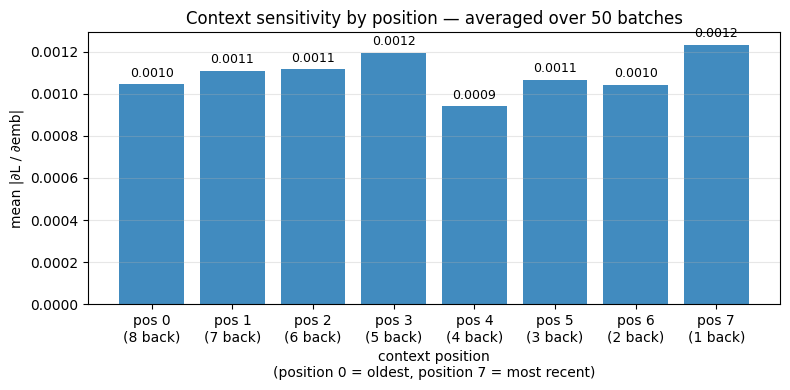


Mean |gradient| by context position:
  pos 0 (      oldest): 0.00105
  pos 1 (      7 back): 0.00111
  pos 2 (      6 back): 0.00112
  pos 3 (      5 back): 0.00120
  pos 4 (      4 back): 0.00094
  pos 5 (      3 back): 0.00107
  pos 6 (      2 back): 0.00104
  pos 7 ( most recent): 0.00123

Ratio (most-recent / oldest): 1.18×


In [6]:
# Compute gradient magnitude per context position over multiple batches.
set_layer_training(model, True)   # need gradient flow through BN
block_size = meta['block_size']

batch_size = 128
n_batches = 50
grad_by_position = torch.zeros(block_size)

for b in range(n_batches):
    ix = torch.randint(0, Xdev.shape[0], (batch_size,))
    Xb, Yb = Xdev[ix], Ydev[ix]

    # Forward, retaining the embedding output for gradient.
    emb = model.layers[0](Xb)             # (B, 8, n_embd)
    emb.retain_grad()
    x = emb
    for layer in model.layers[1:]:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Zero parameter grads (we only care about emb.grad).
    for p in model.parameters():
        p.grad = None
    loss.backward()

    # Average |grad| across batch and embedding dim, leaving position-only.
    grad_by_position += emb.grad.abs().mean(dim=(0, 2))

grad_by_position /= n_batches
set_layer_training(model, False)

# Plot.
fig, ax = plt.subplots(figsize=(8, 4))
positions = list(range(block_size))
bars = ax.bar(positions, grad_by_position.numpy(), color='tab:blue', alpha=0.85)
ax.set_xticks(positions)
ax.set_xticklabels([f'pos {p}\n({block_size-p} back)' for p in positions])
ax.set_xlabel('context position\n(position 0 = oldest, position 7 = most recent)')
ax.set_ylabel('mean |∂L / ∂emb|')
ax.set_title('Context sensitivity by position — averaged over 50 batches')
ax.grid(True, alpha=0.3, axis='y')

# Annotate each bar.
for b, v in zip(bars, grad_by_position):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + b.get_height()*0.02,
            f'{v.item():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/context_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

# Print the numerical results.
print("\nMean |gradient| by context position:")
for p, v in enumerate(grad_by_position):
    age_label = 'oldest' if p == 0 else ('most recent' if p == block_size - 1 else f'{block_size - p} back')
    print(f"  pos {p} ({age_label:>12}): {v.item():.5f}")
print(f"\nRatio (most-recent / oldest): {(grad_by_position[-1] / grad_by_position[0]).item():.2f}×")

## Analysis 4 — Single-unit ablation

The most active neurons at each hierarchical level may be the most causally important for the model's predictions, or they may be redundant — their function may be distributed across many neurons such that knocking out any one is harmless. Ablation distinguishes these cases.

**Procedure**:
1. At each hierarchical level (each Tanh layer's output), compute the mean absolute activation per neuron across a held-out batch.
2. Select the top-5 by mean activation.
3. For each selected neuron, zero its output during a forward pass on the dev set and measure the resulting change in dev loss.
4. Report the loss delta per neuron — the magnitude is the ablation importance estimate.

**Framing constraint**. The correct claim is: *neurons with high mean activation and large ablation effect are estimated to be the most causally influential for overall prediction quality*. This is not the same as: *neuron X encodes feature Y*. Identifying what a specific neuron encodes requires the max-activating examples technique (find the inputs that most activate the neuron, look for patterns), or causal interventions that target specific input features. Those are out of scope here.

What ablation *can* tell us:
- Whether high-activation neurons are doing meaningful work or are redundant.
- The relative magnitude of importance across the three hierarchical levels — is the model's prediction quality more sensitive to bigram-level neurons or 8-gram-level neurons?

What ablation *cannot* tell us:
- Which specific phonological pattern a given neuron encodes.
- Whether the model has discovered any "feature circuit" in the transformer-circuits sense.
- The model's behavior on inputs different from the training distribution.

In [7]:
# Identify the indices of the three Tanh layers in the Sequential.
tanh_indices = [i for i, layer in enumerate(model.layers) if isinstance(layer, Tanh)]
print(f"Tanh layer indices in model.layers: {tanh_indices}")

# Compute mean |activation| per neuron at each level on a representative batch.
set_layer_training(model, False)
with torch.no_grad():
    x = Xdev[:5000]
    level_acts = []
    for i, layer in enumerate(model.layers):
        x = layer(x)
        if i in tanh_indices:
            level_acts.append(x.detach())   # shape (B, T, n_hidden) or (B, n_hidden)

# Reduce to mean |activation| per neuron (averaging over batch + time if applicable).
mean_abs_per_neuron = []
for acts in level_acts:
    if acts.ndim == 3:
        m = acts.abs().mean(dim=(0, 1))     # (n_hidden,)
    else:
        m = acts.abs().mean(dim=0)
    mean_abs_per_neuron.append(m)

# Pick top-5 most active per level.
top5_per_level = []
for level, m in enumerate(mean_abs_per_neuron):
    top5 = torch.topk(m, k=5).indices.tolist()
    top5_per_level.append(top5)
    print(f"\nLevel {level + 1} ({level_names[level]}) — top-5 neurons by mean|activation|:")
    for n in top5:
        print(f"  neuron {n:3d}: mean|activation| = {m[n].item():.3f}")

Tanh layer indices in model.layers: [4, 8, 12]

Level 1 (bigram (level 1)) — top-5 neurons by mean|activation|:
  neuron  67: mean|activation| = 0.533
  neuron  58: mean|activation| = 0.527
  neuron  61: mean|activation| = 0.509
  neuron  55: mean|activation| = 0.507
  neuron  46: mean|activation| = 0.496

Level 2 (4-gram (level 2)) — top-5 neurons by mean|activation|:
  neuron  99: mean|activation| = 0.648
  neuron  97: mean|activation| = 0.628
  neuron  64: mean|activation| = 0.625
  neuron  90: mean|activation| = 0.624
  neuron  68: mean|activation| = 0.624

Level 3 (8-gram (level 3)) — top-5 neurons by mean|activation|:
  neuron  62: mean|activation| = 0.856
  neuron 109: mean|activation| = 0.832
  neuron  89: mean|activation| = 0.828
  neuron  44: mean|activation| = 0.778
  neuron 108: mean|activation| = 0.747


In [8]:
# Baseline dev loss with no ablation.
baseline_dev_loss = evaluate(model, Xdev, Ydev)
print(f"Baseline dev NLL: {baseline_dev_loss:.4f}\n")

# Ablation: zero a specific neuron's output during the forward pass, then evaluate.
def evaluate_with_ablation(model, X, Y, layer_idx, neuron_idx):
    """Forward X through the model, zeroing out (layer_idx, neuron_idx) output.

    Returns the cross-entropy loss on Y under the ablation.
    """
    set_layer_training(model, False)
    with torch.no_grad():
        x = X
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == layer_idx:
                # Zero the target neuron's activation. The tensor shape may be
                # (B, T, n_hidden) for levels 1-2 or (B, n_hidden) for level 3.
                if x.ndim == 3:
                    x = x.clone()
                    x[:, :, neuron_idx] = 0.0
                else:
                    x = x.clone()
                    x[:, neuron_idx] = 0.0
        loss = F.cross_entropy(x, Y).item()
    return loss

# Run the ablation sweep.
print(f"{'Level':<25} {'Neuron':>7} {'Loss after ablation':>22} {'Δ from baseline':>18}")
print("-" * 75)

results = []
for level, tanh_idx in enumerate(tanh_indices):
    for neuron in top5_per_level[level]:
        ablated_loss = evaluate_with_ablation(model, Xdev, Ydev, tanh_idx, neuron)
        delta = ablated_loss - baseline_dev_loss
        results.append((level, neuron, ablated_loss, delta))
        print(f"{level_names[level]:<25} {neuron:>7d} {ablated_loss:>22.4f} {delta:>+18.4f}")

# Sort by largest delta to find the most causally important.
print("\n--- Ranked by ablation impact (largest loss increase first) ---")
for level, neuron, loss, delta in sorted(results, key=lambda r: -r[3])[:10]:
    print(f"  Level {level+1} neuron {neuron:>3}: Δloss = {delta:+.4f}")

Baseline dev NLL: 2.0106

Level                      Neuron    Loss after ablation    Δ from baseline
---------------------------------------------------------------------------


bigram (level 1)               67                 2.0144            +0.0038


bigram (level 1)               58                 2.0129            +0.0023


bigram (level 1)               61                 2.0134            +0.0028


bigram (level 1)               55                 2.0135            +0.0029


...

4-gram (level 2)               68                 2.0166            +0.0060


8-gram (level 3)               62                 2.0318            +0.0212


8-gram (level 3)              109                 2.0347            +0.0241


8-gram (level 3)               89                 2.0374            +0.0268


8-gram (level 3)               44                 2.0242            +0.0135
8-gram (level 3)              108                 2.0179            +0.0073

--- Ranked by ablation impact (largest loss increase first) ---
  Level 3 neuron  89: Δloss = +0.0268
  Level 3 neuron 109: Δloss = +0.0241
  Level 3 neuron  62: Δloss = +0.0212
  Level 3 neuron  44: Δloss = +0.0135
  Level 3 neuron 108: Δloss = +0.0073
  Level 2 neuron  68: Δloss = +0.0060
  Level 2 neuron  97: Δloss = +0.0045
  Level 2 neuron  64: Δloss = +0.0040
  Level 1 neuron  46: Δloss = +0.0040
  Level 1 neuron  67: Δloss = +0.0038


## What this probing analysis does and does not show

The four analyses produced concrete numbers. Briefly:

| Analysis | Headline finding |
|---|---|
| Embedding geometry | Vowels cluster (mean cos = 0.18); consonants do not (≈ 0); boundary `.` is vowel-affine (0.27) |
| Activation distributions | Saturation 9.8% / 12.0% / 5.4% across the three levels — all healthy |
| Context sensitivity | Gradient magnitude is **nearly flat** across all 8 positions (most-recent/oldest ratio = 1.18×) |
| Single-unit ablation | Level 3 (8-gram) neurons dominate causal importance (Δloss up to +0.027); Levels 1-2 contribute much less (+0.002 to +0.006) |

**What the analyses establish, taken together:**

- The embedding space has learned a *partial* category structure. The vowel/consonant distinction is robust and measurable; finer phonological categories are not clearly visible at this 24-dimensional scale. The boundary token's vowel-affinity is consistent with the bigram statistics of the corpus.

- All three hierarchical levels operate in healthy regimes. The engineering protocol from Part 3 (Kaiming + BatchNorm) transferred cleanly into the deeper Part 5 architecture; nothing has saturated, nothing has collapsed.

- **The context-sensitivity result is the most surprising finding.** A naive prior would predict that the most recent position dominates (the immediately-preceding character provides the strongest signal for next-character prediction). The data shows the opposite: the gradient signal is approximately uniform across all 8 positions, with a most-recent/oldest ratio of only 1.18×. The hierarchical receptive field has distributed sensitivity across the entire context rather than concentrating it at the recent end. Whether this reflects (a) the model genuinely using long-range information for prediction, (b) the hierarchical aggregation forcing every position to flow into the final representation regardless of true causal importance, or (c) gradient magnitude being a poor proxy in this architecture, is *not* settled by probing alone. The differences between these hypotheses matter and would require additional intervention experiments to distinguish.

- **The ablation results reveal a clear hierarchy in causal importance.** Knocking out a single high-activation neuron at the 8-gram level can increase dev loss by ~+0.025 nats (≈ 1.3% relative); the same operation at the bigram or 4-gram level rarely exceeds +0.006 nats. The 8-gram representation is where the predictive signal is concentrated in the model — which matches the architectural design (the final hierarchical level is the one whose output goes directly to the logit projection) but does not by itself tell us *what* the level-3 neurons are encoding.

**What the analyses do not establish:**

- *Specific feature assignments.* We have not shown that any particular neuron encodes "vowels," "syllable boundaries," or any other named feature. That claim requires max-activating-examples analysis plus targeted interventions — neither of which is in this notebook.

- *Causal feature circuits.* The embedding geometry and activation patterns are correlational characterizations. The ablation experiment is the closest to a causal measurement here, but it tells us about *importance for overall prediction*, not about specific feature pathways. Activation patching — replacing a specific component's activation with a different input's activation and measuring downstream effects — is the standard technique for tracing causal pathways, and is applied to transformer architectures in the `gpt` repository that follows this one.

- *The hierarchy of phonological abstraction we hypothesized.* The architectural promise of WaveNet is that level 1 learns bigram features, level 2 learns 4-gram features, level 3 learns 8-gram features. The ablation results are *consistent* with level 3 being where the most predictive (most aggregated) information lives, but this is also exactly what we'd predict from the architecture alone — the final hierarchical level is closest to the output. We cannot conclude that level 1 is specifically learning bigram-level phonological features without inspecting *what* its high-activation neurons fire on, which we have not done.

**Methodological honesty.** PCA projections discard 78% of the variance at this dimensionality. K-means with k=5 imposes a specific partition geometry; cluster assignments shift meaningfully under different k values. Gradient magnitude is one sensitivity measure among many (input × gradient, integrated gradients, occlusion); they sometimes disagree. Single-unit ablation tests removal, not perturbation, and may underestimate distributed-representation effects.

**The honest signal-to-noise summary.** The clearest results above are the activation-distribution diagnostics (engineering-quality numbers) and the ablation hierarchy across levels (concrete, ranked, interpretable). The embedding-geometry vowel finding is real and well-supported. The context-sensitivity flatness is the genuinely surprising result and deserves follow-up — distinguishing the three hypotheses above (real long-range use vs. aggregation artifact vs. proxy weakness) requires intervention experiments beyond what probing alone can provide.

**What comes next.** Probing identifies *what the representations look like*. Moving from probing correlations to identifying causal mechanisms — answering "is this neuron actually used by the model to detect vowels, or does it just happen to fire on them?" — requires intervention techniques (activation patching, causal scrubbing, attribution patching) that are most natural on architectures with a residual stream and attention. That work is taken up in the `gpt` repository on transformer architectures.